<a href="https://colab.research.google.com/github/afifamaisha13/NargisMam-Digital_Image_processing-4.1/blob/main/Lab_2_%26_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install dependency
!pip install pillow

from PIL import Image
from google.colab import files
import io

# ---------- Steganography Functions ----------

def to_binary(message):
    return ''.join(format(ord(i), '08b') for i in message) + '11111110'

def encode_image(image, message):
    binary = to_binary(message)
    index = 0

    img = image.copy()
    pixels = img.load()

    for i in range(img.size[0]):
        for j in range(img.size[1]):
            r, g, b = pixels[i, j]

            if index < len(binary):
                r = (r & ~1) | int(binary[index])
                index += 1
            if index < len(binary):
                g = (g & ~1) | int(binary[index])
                index += 1
            if index < len(binary):
                b = (b & ~1) | int(binary[index])
                index += 1

            pixels[i, j] = (r, g, b)

            if index >= len(binary):
                return img

    return img

def decode_image(image):
    binary = ""
    pixels = image.load()

    for i in range(image.size[0]):
        for j in range(image.size[1]):
            r, g, b = pixels[i, j]
            binary += str(r & 1)
            binary += str(g & 1)
            binary += str(b & 1)

    all_bytes = [binary[i:i+8] for i in range(0, len(binary), 8)]

    message = ""
    for byte in all_bytes:
        if byte == '11111110':
            break
        message += chr(int(byte, 2))

    return message

# ---------- MENU ----------

print("Choose option:")
print("1 - Encode Message")
print("2 - Decode Message")

choice = input("Enter 1 or 2: ")

# ---------- ENCODE ----------

if choice == '1':
    print("\nUpload an image:")
    uploaded = files.upload()

    for file_name in uploaded.keys():
        img = Image.open(io.BytesIO(uploaded[file_name]))
        img = img.convert('RGB') # Convert to RGB to handle potential RGBA images

        message = input("Enter secret message: ")

        encoded_img = encode_image(img, message)

        encoded_img.save("encoded.png")
        print("✅ Message encoded successfully!")

        files.download("encoded.png")

# ---------- DECODE ----------

elif choice == '2':
    print("\nUpload encoded image:")
    uploaded = files.upload()

    for file_name in uploaded.keys():
        img = Image.open(io.BytesIO(uploaded[file_name]))

        message = decode_image(img)

        print("✅ Hidden Message:", message)

else:
    print("Invalid choice")

Choose option:
1 - Encode Message
2 - Decode Message
Enter 1 or 2: 2

Upload encoded image:


Saving encoded.png to encoded (1).png
✅ Hidden Message: I am Afifa.


Upload first image


Saving image_1777954226889.png to image_1777954226889.png
Upload second image


Saving image_1777954216536.png to image_1777954216536.png


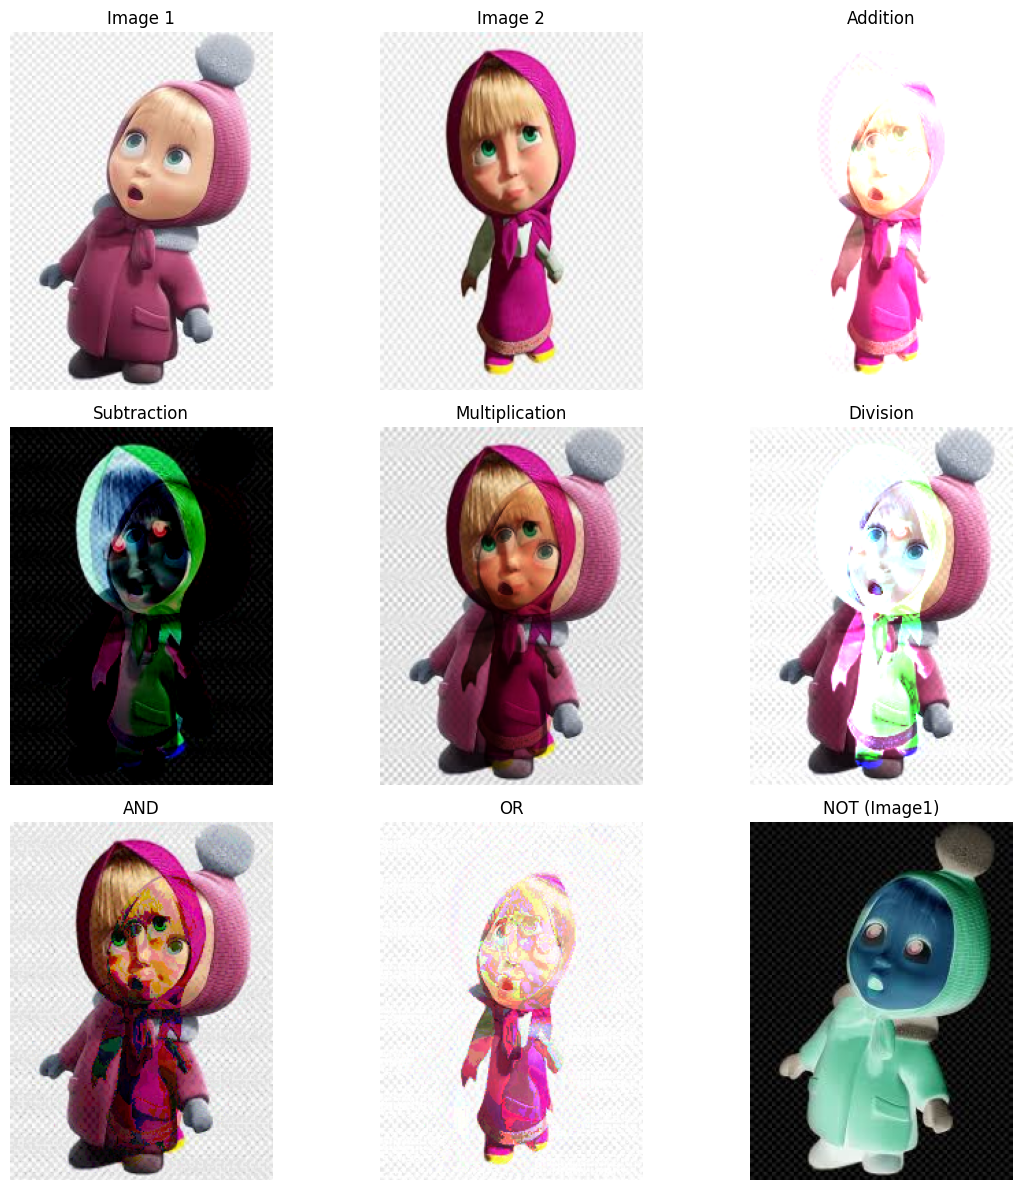

All operations completed and saved successfully!


In [4]:
# Install required library (if needed)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ---------- Upload Images ----------
print("Upload first image")
uploaded1 = files.upload()

print("Upload second image")
uploaded2 = files.upload()

# Get file names
img1_name = list(uploaded1.keys())[0]
img2_name = list(uploaded2.keys())[0]

# Read Images
img1 = cv2.imread(img1_name)
img2 = cv2.imread(img2_name)

# Convert BGR to RGB (for display)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Resize second image to match first image size
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Convert to float for arithmetic operations
img1_d = img1.astype(np.float64) / 255.0
img2_d = img2.astype(np.float64) / 255.0

# ---------- Arithmetic Operations ----------
add_img = np.clip(img1_d + img2_d, 0, 1)
sub_img = np.clip(img1_d - img2_d, 0, 1)
mul_img = np.clip(img1_d * img2_d, 0, 1)
div_img = np.clip(img1_d / (img2_d + 0.01), 0, 1)

# ---------- Logical Operations ----------
and_img = cv2.bitwise_and(img1, img2)
or_img  = cv2.bitwise_or(img1, img2)
not_img = cv2.bitwise_not(img1)

# Convert arithmetic images back to uint8
add_img_u = (add_img * 255).astype(np.uint8)
sub_img_u = (sub_img * 255).astype(np.uint8)
mul_img_u = (mul_img * 255).astype(np.uint8)
div_img_u = (div_img * 255).astype(np.uint8)

# ---------- Display Results ----------
titles = ['Image 1', 'Image 2', 'Addition',
          'Subtraction', 'Multiplication', 'Division',
          'AND', 'OR', 'NOT (Image1)']

images = [img1, img2, add_img_u,
          sub_img_u, mul_img_u, div_img_u,
          and_img, or_img, not_img]

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# ---------- Save Output Images ----------
cv2.imwrite('add.jpg', cv2.cvtColor(add_img_u, cv2.COLOR_RGB2BGR))
cv2.imwrite('sub.jpg', cv2.cvtColor(sub_img_u, cv2.COLOR_RGB2BGR))
cv2.imwrite('mul.jpg', cv2.cvtColor(mul_img_u, cv2.COLOR_RGB2BGR))
cv2.imwrite('div.jpg', cv2.cvtColor(div_img_u, cv2.COLOR_RGB2BGR))
cv2.imwrite('and.jpg', cv2.cvtColor(and_img, cv2.COLOR_RGB2BGR))
cv2.imwrite('or.jpg', cv2.cvtColor(or_img, cv2.COLOR_RGB2BGR))
cv2.imwrite('not.jpg', cv2.cvtColor(not_img, cv2.COLOR_RGB2BGR))

print("All operations completed and saved successfully!")

Saving image_1777954226889.png to image_1777954226889 (1).png
Image shape: (262, 192)
[[255 255 249 ... 236 228 225]
 [255 255 251 ... 234 228 227]
 [250 251 249 ... 236 233 235]
 ...
 [236 234 237 ... 243 249 251]
 [229 228 234 ... 247 255 255]
 [233 229 230 ... 251 255 255]]


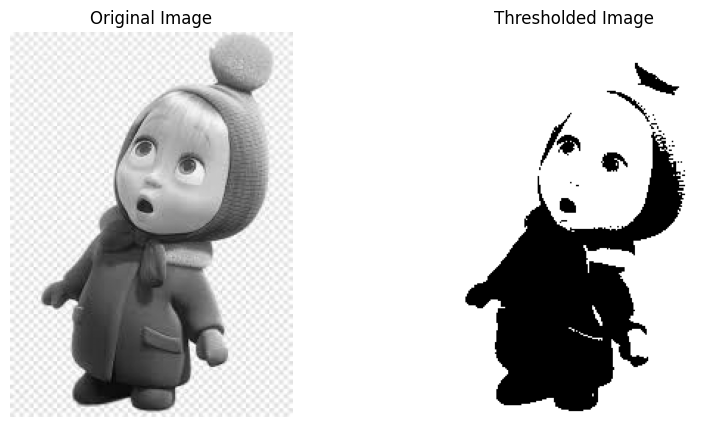

Thresholding completed and image saved.


In [5]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get filename
img_name = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(img_name, cv2.IMREAD_GRAYSCALE)

# Show image size
print("Image shape:", img.shape)

# Display some pixel values
#print("Pixel value at (0,0):", img[0,0])
#print("Pixel value at (50,50):", img[50,50])
#print("Pixel value at (100,100):", img[100,100])
print(img)

# Thresholding:
# 0-128 -> 0
# 129-255 -> 255
threshold_img = np.where(img <= 128, 0, 255).astype(np.uint8)

# Display original and thresholded image
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(threshold_img, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')

plt.show()

# Save thresholded image
cv2.imwrite('threshold_output.png', threshold_img)

print("Thresholding completed and image saved.")

In [ ]:
lab2:take two input image and perform addition, subtraction, multiplication, division and logical operation(and ,or ,not)
lab 3:take an image find its pixel value and do thresholding where 0-128 = 0 and 129-255 =255